<a href="https://colab.research.google.com/github/anbarasanhere/Ensemble-Learning-OLA/blob/main/Ola_ensemble_cs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Business Case: OLA - Ensemble Learning**



**TASK**

> to predict whether a driver will be leaving the company or not
> by using necessary attributes:

---






**Column Profiling:**

- MMMM-YY : Reporting Date (Monthly)
- Driver_ID : Unique id for drivers
-Age : Age of the driver
-Gender : Gender of the driver – Male : 0, Female: 1
-City : City Code of the driver
-Education_Level : Education level – 0 for 10+ ,1 for 12+ ,2 for graduate
-Income : Monthly average Income of the driver
-Date Of Joining : Joining date for the driver
-LastWorkingDate : Last date of working for the driver
-Joining Designation : Designation of the driver at the time of joining
-Grade : Grade of the driver at the time of reporting
-Total Business Value : The total business value acquired by the driver in a -month (negative business indicates cancellation/refund or car EMI adjustments)
-Quarterly Rating : Quarterly rating of the driver: 1,2,3,4,5 (higher is better)

**1.Define Problem Statement and perform Exploratory Data Analysis**

In [ ]:
# importing dependencies for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

import time

In [ ]:
# importing data set
df_original = pd.read_csv('/content/drive/MyDrive/[01]DataScience/Data sets/Python files/CSV files/ML dataset/ola_driver_scaler.csv')

In [ ]:
df=df_original.copy()

In [ ]:
df.head()

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [ ]:
df.shape

(19104, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


In [ ]:
# dropping unnamed column
df.drop(columns='Unnamed: 0', inplace=True)

In [ ]:
df.columns

Index(['MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City', 'Education_Level',
       'Income', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation',
       'Grade', 'Total Business Value', 'Quarterly Rating'],
      dtype='object')

In [ ]:
# convert 'date' column to datetime
df['MMM-YY'] = pd.to_datetime(df['MMM-YY'])
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'])
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'])

/tmp/ipython-input-9-1912243245.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['MMM-YY'] = pd.to_datetime(df['MMM-YY'])
/tmp/ipython-input-9-1912243245.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'])
/tmp/ipython-input-9-1912243245.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   MMM-YY                19104 non-null  datetime64[ns]
 1   Driver_ID             19104 non-null  int64         
 2   Age                   19043 non-null  float64       
 3   Gender                19052 non-null  float64       
 4   City                  19104 non-null  object        
 5   Education_Level       19104 non-null  int64         
 6   Income                19104 non-null  int64         
 7   Dateofjoining         19104 non-null  datetime64[ns]
 8   LastWorkingDate       1616 non-null   datetime64[ns]
 9   Joining Designation   19104 non-null  int64         
 10  Grade                 19104 non-null  int64         
 11  Total Business Value  19104 non-null  int64         
 12  Quarterly Rating      19104 non-null  int64         
dtypes: datetime64[ns

In [ ]:
# Checking null values
df.isnull().sum().sort_values(ascending=False)
print(df.isnull().sum()/len(df)*100)

MMM-YY                   0.000000
Driver_ID                0.000000
Age                      0.319305
Gender                   0.272194
City                     0.000000
Education_Level          0.000000
Income                   0.000000
Dateofjoining            0.000000
LastWorkingDate         91.541039
Joining Designation      0.000000
Grade                    0.000000
Total Business Value     0.000000
Quarterly Rating         0.000000
dtype: float64


- LastWorkingDate missing values represents, Driver has not left the company yet.

In [ ]:
df.nunique()

,0
MMM-YY,24
Driver_ID,2381
Age,36
Gender,2
City,29
Education_Level,3
Income,2383
Dateofjoining,869
LastWorkingDate,493
Joining Designation,5


In [ ]:
# numerical columns
num_cols = df.select_dtypes(np.number)
print(num_cols.columns)

Index(['Driver_ID', 'Age', 'Gender', 'Education_Level', 'Income',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')


In [ ]:
num_cols.drop(['Driver_ID'], axis=1, inplace=True)

In [ ]:
# KNN Imputation of Missing Values
imputer = KNNImputer(n_neighbors=5, weights='uniform', metric='nan_euclidean') #initializing the function & its parameters
imputer.fit(num_cols)
new_data = imputer.transform(num_cols)

In [ ]:
new_data = pd.DataFrame(new_data)

In [ ]:
new_data.columns = num_cols.columns

In [ ]:
new_data.columns

Index(['Age', 'Gender', 'Education_Level', 'Income', 'Joining Designation',
       'Grade', 'Total Business Value', 'Quarterly Rating'],
      dtype='object')

In [ ]:
print(new_data.isnull().sum()/ len(new_data) * 100) # % of missing values after KNNImputation

Age                     0.0
Gender                  0.0
Education_Level         0.0
Income                  0.0
Joining Designation     0.0
Grade                   0.0
Total Business Value    0.0
Quarterly Rating        0.0
dtype: float64


In [ ]:
# concating dataframes
resultant_columns = list(set(df.columns).difference(set(num_cols)))
resultant_columns

['MMM-YY', 'LastWorkingDate', 'Dateofjoining', 'City', 'Driver_ID']

In [ ]:
new_df = pd.concat([new_data, df[resultant_columns]], axis=1)
new_df.shape

(19104, 13)

In [ ]:
new_df.head()

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,MMM-YY,LastWorkingDate,Dateofjoining,City,Driver_ID
0,28.0,0.0,2.0,57387.0,1.0,1.0,2381060.0,2.0,2019-01-01,NaT,2018-12-24,C23,1
1,28.0,0.0,2.0,57387.0,1.0,1.0,-665480.0,2.0,2019-02-01,NaT,2018-12-24,C23,1
2,28.0,0.0,2.0,57387.0,1.0,1.0,0.0,2.0,2019-03-01,2019-03-11,2018-12-24,C23,1
3,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,2020-11-01,NaT,2020-11-06,C7,2
4,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,2020-12-01,NaT,2020-11-06,C7,2


**2.Data Preprocessing**

In [ ]:
# Feature Engineering
agg_functions = {
    "Age":"max",
    "Gender": "first",
    "Education_Level": "last",
    "Income": "last",
    "Joining Designation": "last",
    "Grade": "last",
    "Total Business Value": "sum",
    "Quarterly Rating": "last",
    "LastWorkingDate": "last",
    "City": "first",
    "Dateofjoining": "last"
}

processed_df = new_df.groupby(['Driver_ID', 'MMM-YY']).aggregate(agg_functions).sort_index(ascending = [True,True])
processed_df

Age  Gender  Education_Level   Income  \
Driver_ID MMM-YY                                               
1         2019-01-01  28.0     0.0              2.0  57387.0   
          2019-02-01  28.0     0.0              2.0  57387.0   
          2019-03-01  28.0     0.0              2.0  57387.0   
2         2020-11-01  31.0     0.0              2.0  67016.0   
          2020-12-01  31.0     0.0              2.0  67016.0   
...                    ...     ...              ...      ...   
2788      2020-08-01  30.0     0.0              2.0  70254.0   
          2020-09-01  30.0     0.0              2.0  70254.0   
          2020-10-01  30.0     0.0              2.0  70254.0   
          2020-11-01  30.0     0.0              2.0  70254.0   
          2020-12-01  30.0     0.0              2.0  70254.0   

                      Joining Designation  Grade  Total Business Value  \
Driver_ID MMM-YY                                                         
1         2019-01-01                  1.0    1.0             2381060.0   
          2019-02-01                  1.0    1.0             -665480.0   
          2019-03-01                  1.0    1.0                   0.0   
2         2020-11-01                  2.0    2.0                   0.0   
          2020-12-01                  2.0    2.0                   0.0   
...                                   ...    ...                   ...   
2788      2020-08-01                  2.0    2.0              740280.0   
          2020-09-01                  2.0    2.0              448370.0   
          2020-10-01                  2.0    2.0                   0.0   
          2020-11-01                  2.0    2.0              200420.0   
          2020-12-01                  2.0    2.0              411480.0   

                      Quarterly Rating LastWorkingDate City Dateofjoining  
Driver_ID MMM-YY                                                           
1         2019-01-01               2.0             NaT  C23    2018-12-24  
          2019-02-01               2.0             NaT  C23    2018-12-24  
          2019-03-01               2.0      2019-03-11  C23    2018-12-24  
2         2020-11-01               1.0             NaT   C7    2020-11-06  
          2020-12-01               1.0             NaT   C7    2020-11-06  
...                                ...             ...  ...           ...  
2788      2020-08-01               3.0             NaT  C27    2020-06-08  
          2020-09-01               3.0             NaT  C27    2020-06-08  
          2020-10-01               2.0             NaT  C27    2020-06-08  
          2020-11-01               2.0             NaT  C27    2020-06-08  
          2020-12-01               2.0             NaT  C27    2020-06-08  

[19104 rows x 11 columns]

In [ ]:
final_data = pd.DataFrame()

In [ ]:
final_data['Driver_ID'] = new_df['Driver_ID'].unique()

In [ ]:
final_data['Age'] = list(processed_df.groupby('Driver_ID', axis=0).max('MMM-YY')['Age'])
final_data['Gender'] = list(processed_df.groupby('Driver_ID').agg({'Gender':'last'})['Gender'])
final_data['City'] = list(processed_df.groupby('Driver_ID').agg({'City':'last'})['City'])
final_data['Education'] = list(processed_df.groupby('Driver_ID').agg({'Education_Level':'last'})['Education_Level'])
final_data['Income'] = list(processed_df.groupby('Driver_ID').agg({'Income':'last'})['Income'])
final_data['Joining_Designation'] = list(processed_df.groupby('Driver_ID').agg({'Joining Designation':'last'})['Joining Designation'])
final_data['Grade'] = list(processed_df.groupby('Driver_ID').agg({'Grade':'last'})['Grade'])
final_data['Total_Business_Value'] = list(processed_df.groupby('Driver_ID',axis=0).sum('Total_Business_Value')['Total Business Value'])
final_data['Last_Quarterly_Rating'] = list(processed_df.groupby('Driver_ID').agg({'Quarterly Rating':'last'})['Quarterly Rating'])

/tmp/ipython-input-26-3716189631.py:1: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  final_data['Age'] = list(processed_df.groupby('Driver_ID', axis=0).max('MMM-YY')['Age'])
/tmp/ipython-input-26-3716189631.py:8: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  final_data['Total_Business_Value'] = list(processed_df.groupby('Driver_ID',axis=0).sum('Total_Business_Value')['Total Business Value'])


In [ ]:
final_data.head()

,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0


In [ ]:
final_data.shape

(2381, 10)

- Create a column which tells whether the quarterly rating has increased for that driver (1-increased, 0-not increased)

In [ ]:
first_quarter = processed_df.groupby(['Driver_ID']).agg({'Quarterly Rating':'first'})
last_quarter = processed_df.groupby(['Driver_ID']).agg({'Quarterly Rating':'last'})
qr = (last_quarter["Quarterly Rating"] > first_quarter["Quarterly Rating"]).reset_index()
empid = qr[qr['Quarterly Rating']==True]['Driver_ID']
qrl = [ ]
for i in final_data['Driver_ID']:
  if i in empid.values:
    qrl.append(1)
  else:
    qrl.append(0)
final_data['Quarterly_Rating_Increased'] = qrl

In [ ]:
final_data.head()

,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,0
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1


In [ ]:
final_data.shape

(2381, 11)

In [ ]:
# lets create target variable
last_WD =(processed_df.groupby(['Driver_ID']).agg({'LastWorkingDate':'last'})['LastWorkingDate'].isna()).reset_index()
last_WD_ID = last_WD[last_WD['LastWorkingDate'] == True]['Driver_ID']

target = [ ]
for i in final_data['Driver_ID']:
  if i in last_WD_ID.values:
    target.append(0)
  else:
    target.append(1)
final_data['target'] = target

In [ ]:
final_data.head()

,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased,target
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0,1
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,0,0
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0,1
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0,1
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1,0


**Column which tells whether the monthly income of driver is increased or not increased-1, no-0**

In [ ]:
mrf = processed_df.groupby(['Driver_ID']).agg({'Income':'first'})
mrl = processed_df.groupby(['Driver_ID']).agg({'Income':'last'})

mr = (mrl['Income'] > mrf['Income']).reset_index()

empid = mr[mr['Income'] == True]['Driver_ID']
income = []
for i in final_data['Driver_ID']:
  if i in empid.values:
    income.append(1)
  else:
    income.append(0)

final_data['Salary_Increased'] = income



In [ ]:
final_data.head()

,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased,target,Salary_Increased
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0,1,0
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,0,0,0
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0,1,0
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0,1,0
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1,0,0


In [ ]:
final_data.Salary_Increased.value_counts(normalize=True)

,proportion
Salary_Increased,
0,0.98194
1,0.01806


In [ ]:
# statistical summary
final_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Driver_ID,2381.0,1.397559e+03,8.061616e+02,1.0,695.0,1400.0,2100.0,2788.0
Age,2381.0,3.377018e+01,5.933265e+00,21.0,30.0,33.0,37.0,58.0
Gender,2381.0,4.105838e-01,4.914963e-01,0.0,0.0,0.0,1.0,1.0
Education,2381.0,1.007560e+00,8.162900e-01,0.0,0.0,1.0,2.0,2.0
Income,2381.0,5.933416e+04,2.838367e+04,10747.0,39104.0,55315.0,75986.0,188418.0
Joining_Designation,2381.0,1.820244e+00,8.414334e-01,1.0,1.0,2.0,2.0,5.0
Grade,2381.0,2.096598e+00,9.415218e-01,1.0,1.0,2.0,3.0,5.0
Total_Business_Value,2381.0,4.586742e+06,9.127115e+06,-1385530.0,0.0,817680.0,4173650.0,95331060.0
Last_Quarterly_Rating,2381.0,1.427971e+00,8.098389e-01,1.0,1.0,1.0,2.0,4.0
Quarterly_Rating_Increased,2381.0,1.503570e-01,3.574961e-01,0.0,0.0,0.0,0.0,1.0


- There are total of 2831 different drivers data.
- Age of drivers range from 21years to 58years.
- 75% drivers monthly income is <= 75986.
- 75% drivers acquired 4173650 as total business values.



In [ ]:
final_data.describe(include='object') # most of the drivers are from C20 city

,City
count,2381
unique,29
top,C20
freq,152


In [ ]:
final_data['Gender'].value_counts()

,count
Gender,
0.0,1400
1.0,975
0.6,3
0.2,2
0.4,1


In [ ]:
cols = ['Education','target']
value_cnt = final_data[cols].apply(pd.value_counts)
print(value_cnt)

     Education  target
0.0        784   765.0
1.0        795  1616.0
2.0        802     NaN


/tmp/ipython-input-40-2988656233.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  value_cnt = final_data[cols].apply(pd.value_counts)


Out of 2381 drivers 1616 drivers have left the company

In [ ]:
# valuecount % for each column in final_data
val_col = ['Gender','Education','Joining_Designation','Grade','Last_Quarterly_Rating','Quarterly_Rating_Increased']
for i in val_col:
  print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
  print(final_data[i].value_counts(normalize=True)*100)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Gender
0.0    58.798824
1.0    40.949181
0.6     0.125997
0.2     0.083998
0.4     0.041999
Name: proportion, dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Education
2.0    33.683326
1.0    33.389332
0.0    32.927341
Name: proportion, dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Joining_Designation
1.0    43.091138
2.0    34.229315
3.0    20.705586
4.0     1.511970
5.0     0.461991
Name: proportion, dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Grade
2.0    35.909282
1.0    31.121378
3.0    26.165477
4.0     5.795884
5.0     1.007980
Name: proportion, dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Last_Quarterly_Rating
1.0    73.246535
2.0    15.203696
3.0     7.055859
4.0     4.493910
Name: proportion, dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Quarterly_Rating_Increased
0    84.964301
1    15.035699
Name: proportion, dtype: float64


- 58% of drivers are male while female constitutes around 40%
- 33% of drivers have completed graduation and 12+ education
- 43% of drivers have 1 as joining_designation
- Around 36% of drivers graded as 2
- Around 73% of drivers rated as 1 on last quarter
- Only 15% of drivers rating has been increased on quarterly

**Univariate Analysis**

In [ ]:
final_data.columns

Index(['Driver_ID', 'Age', 'Gender', 'City', 'Education', 'Income',
       'Joining_Designation', 'Grade', 'Total_Business_Value',
       'Last_Quarterly_Rating', 'Quarterly_Rating_Increased', 'target',
       'Salary_Increased'],
      dtype='object')

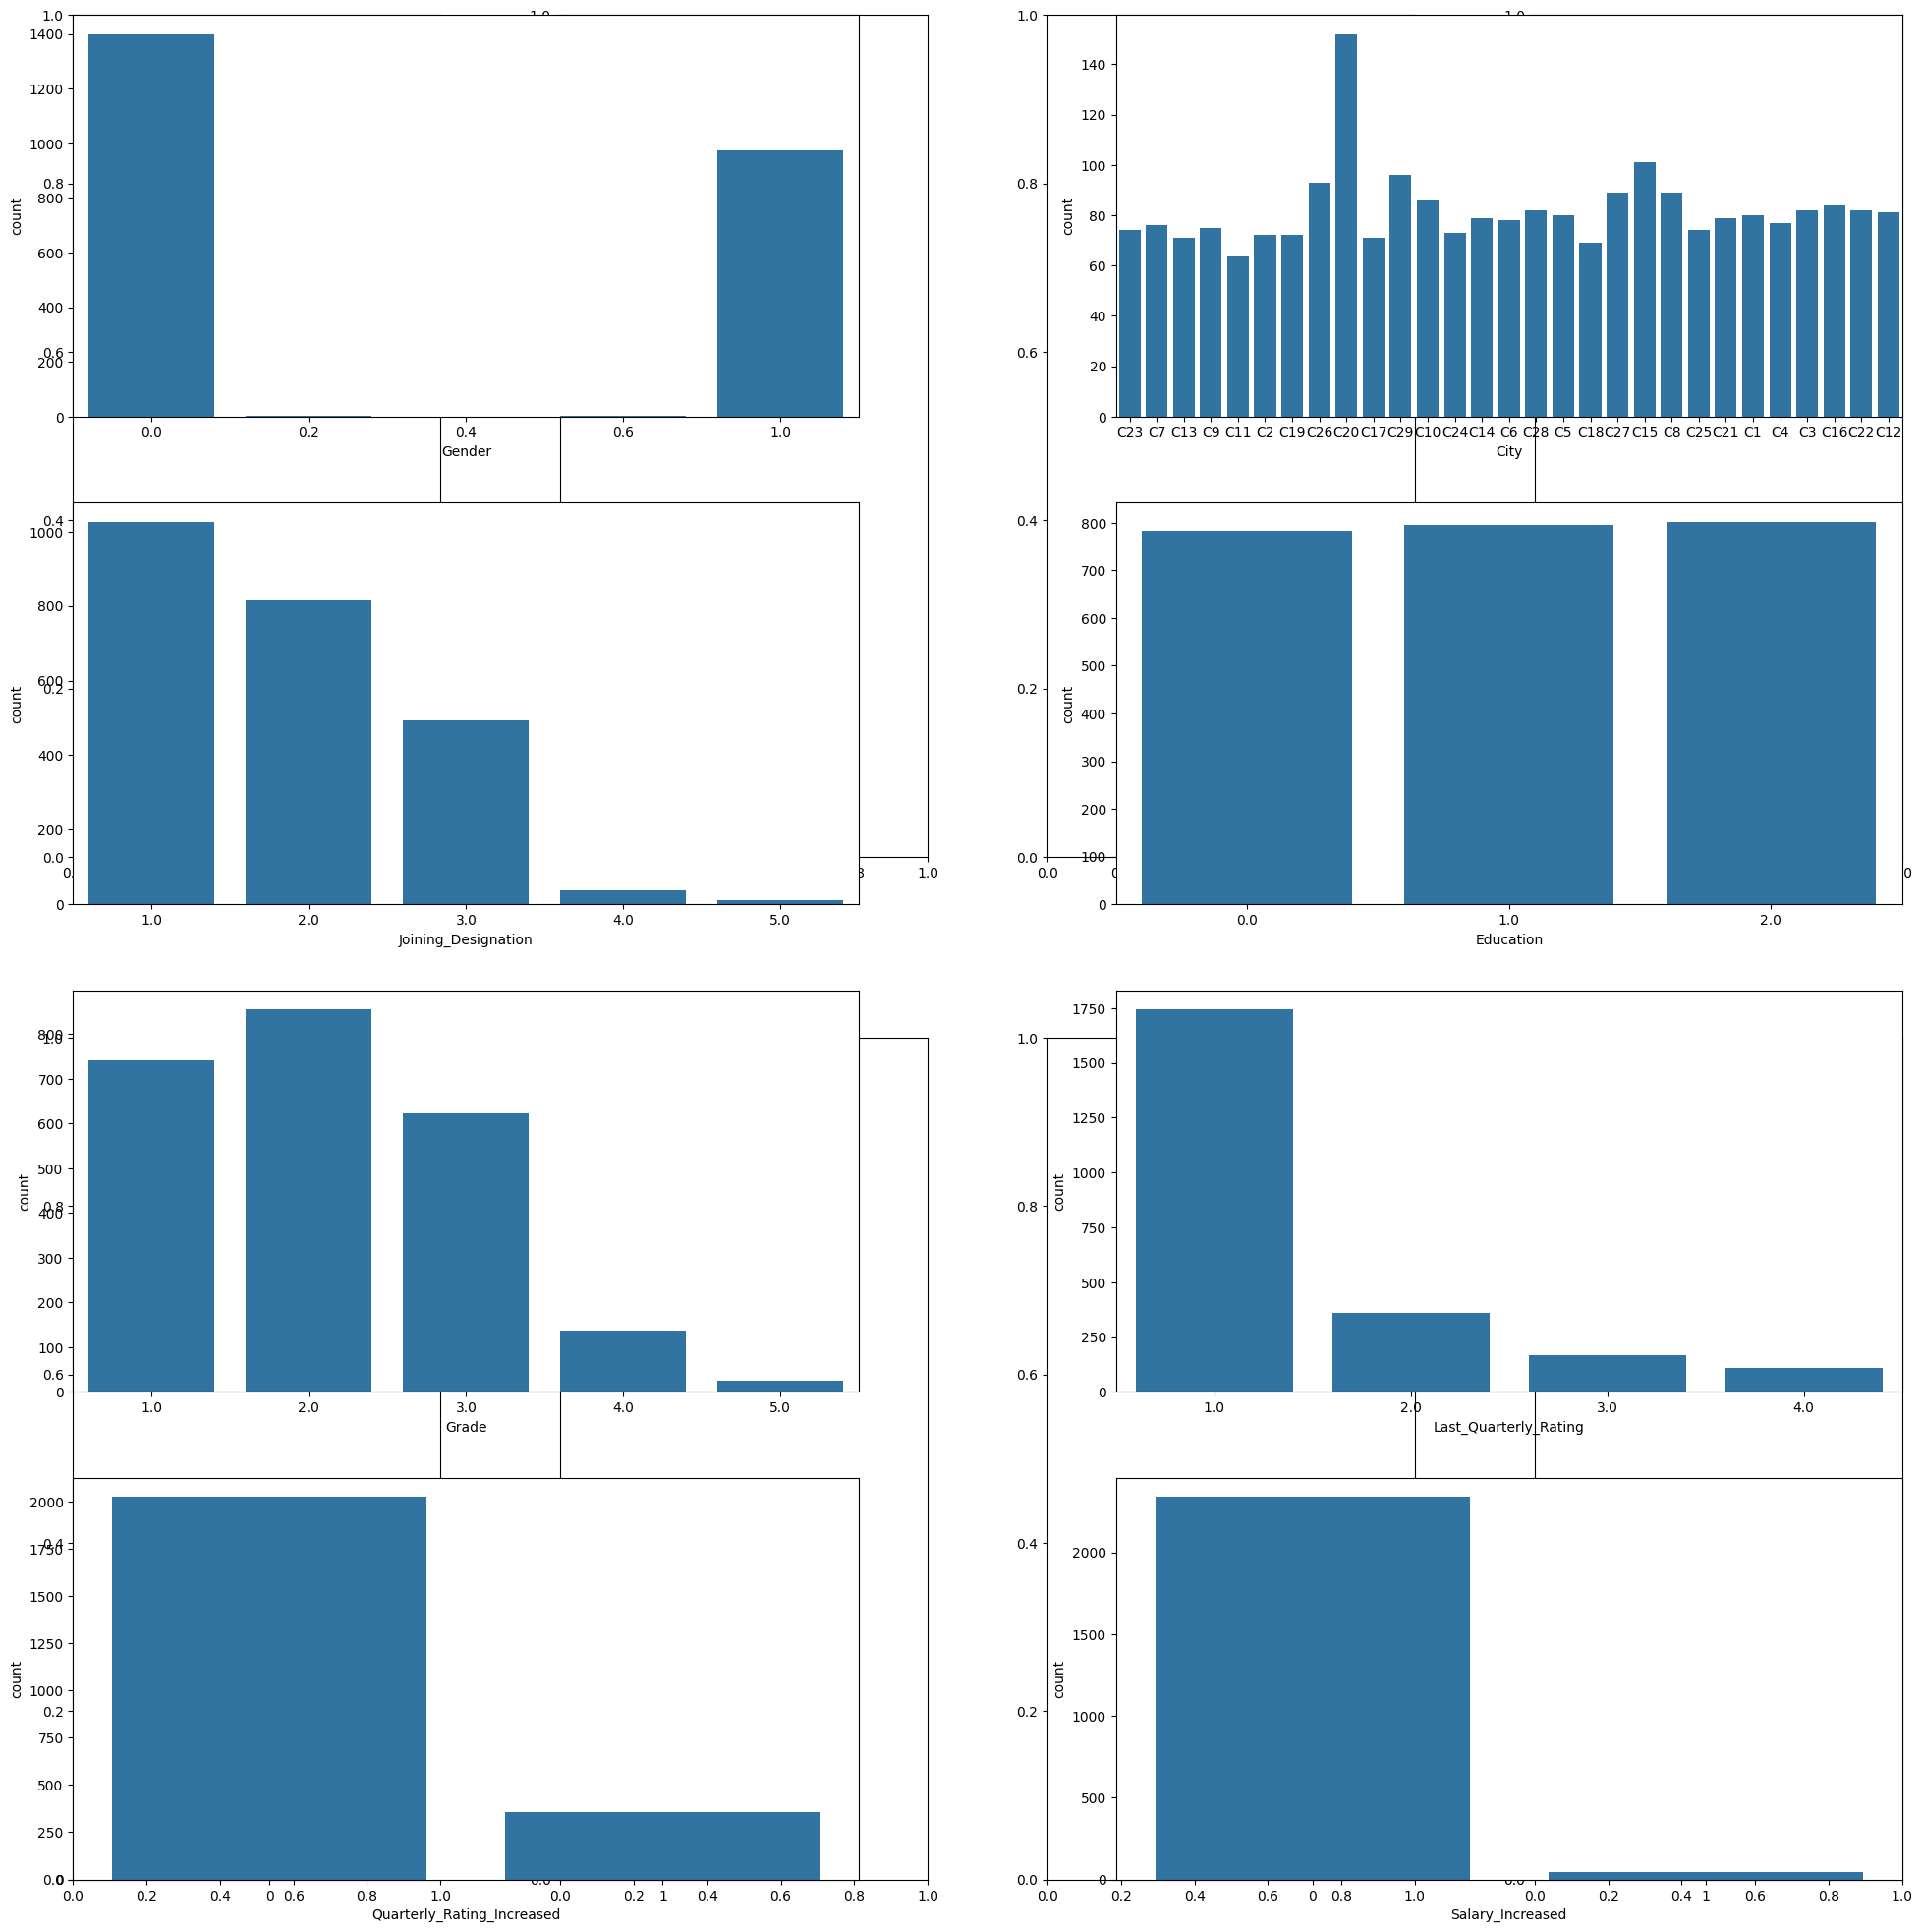

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 20))
plt.subplot(421)
sns.countplot(data=final_data, x="Gender")
# final_data["Gender"].value_counts(normalize=True).plot.bar('Gender')

plt.subplot(422)
sns.countplot(data=final_data, x="City")


plt.subplot(423)
sns.countplot(data=final_data, x="Joining_Designation")

plt.subplot(424)
sns.countplot(data=final_data, x="Education")

plt.subplot(425)
sns.countplot(data=final_data, x="Grade")

plt.subplot(426)
sns.countplot(data=final_data, x="Last_Quarterly_Rating")

plt.subplot(427)
sns.countplot(data=final_data, x="Quarterly_Rating_Increased")

plt.subplot(428)
sns.countplot(data=final_data, x="Salary_Increased")

plt.tight_layout()

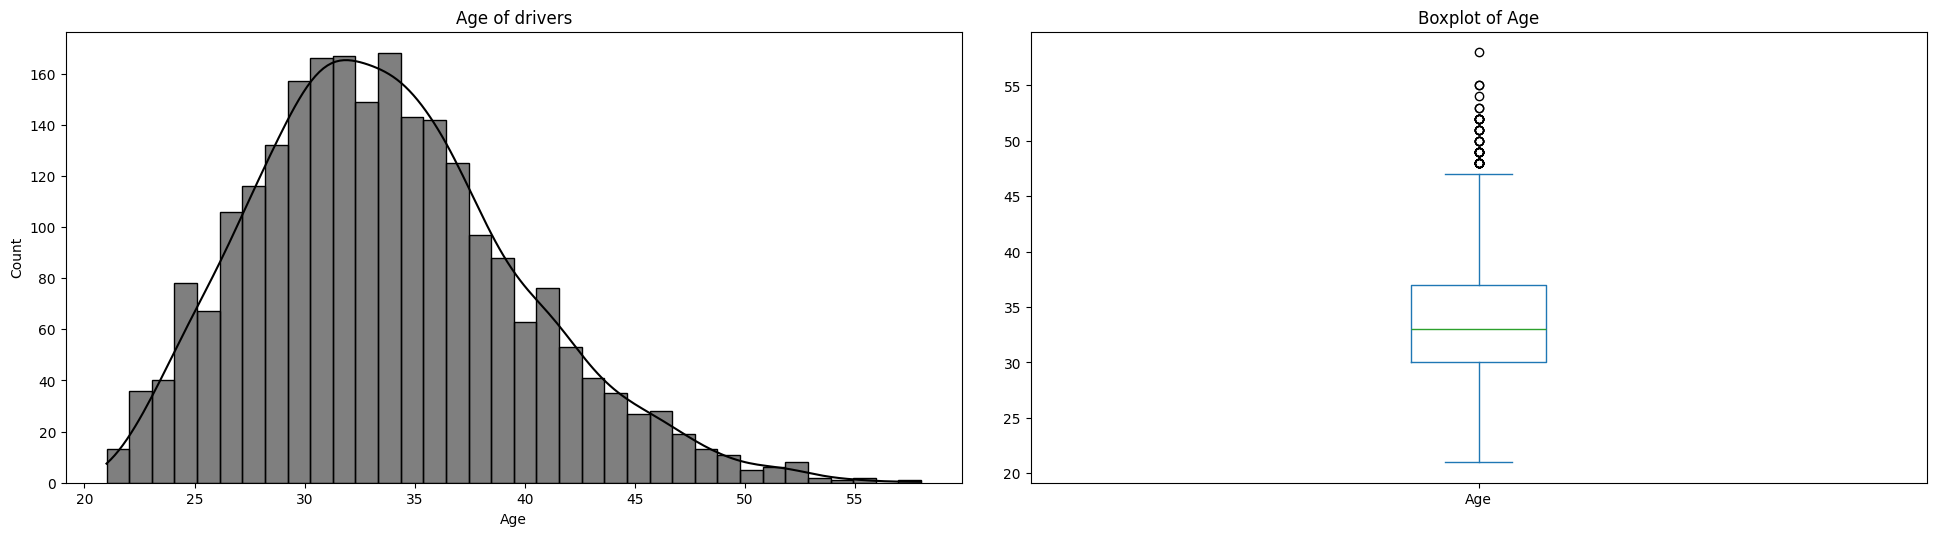

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

plt.subplot(121)
sns.histplot(final_data['Age'],color='black', kde=True)
plt.title("Age of drivers")
# Add xticks to the histogram
plt.xticks(fontsize=10) # You can adjust fontsize as needed

plt.subplot(122)
final_data['Age'].plot.box(title='Boxplot of Age')
# Add xticks to the boxplot
plt.xticks(fontsize=10) # You can adjust fontsize as needed

plt.tight_layout(pad=3)
plt.show()

- The distribution of age is slightly skewed on right side

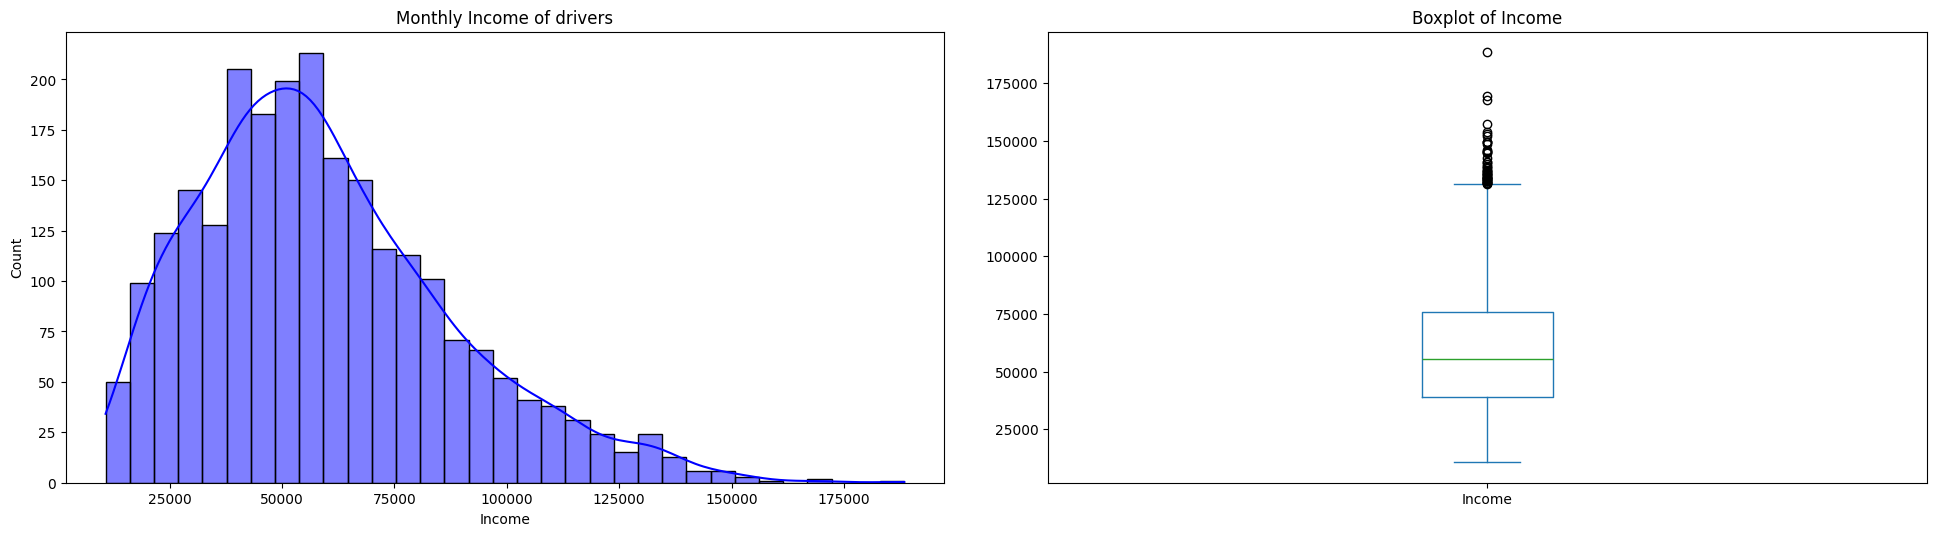

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
plt.subplot(121)
sns.histplot(final_data['Income'],color='blue', kde=True)
plt.title("Monthly Income of drivers")
plt.subplot(122)
final_data['Income'].plot.box(title='Boxplot of Income')
plt.tight_layout(pad=3)

- The distribution of monthly income skewed on right side

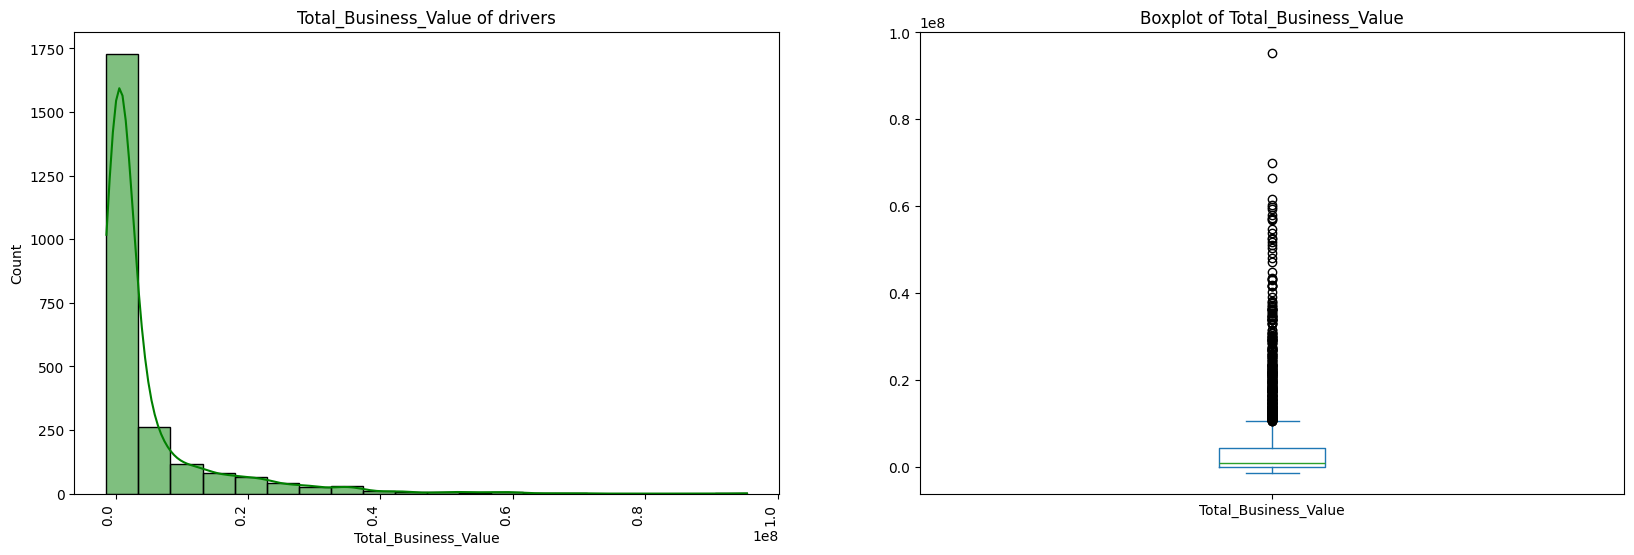

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
plt.subplot(121)
sns.histplot(final_data['Total_Business_Value'],color='green', kde=True, bins=20)
plt.title("Total_Business_Value of drivers")
plt.xticks(rotation=90, ha='right')
plt.subplot(122)
final_data['Total_Business_Value'].plot.box(title='Boxplot of Total_Business_Value')
plt.show()

**Bi-Variate Analysis**

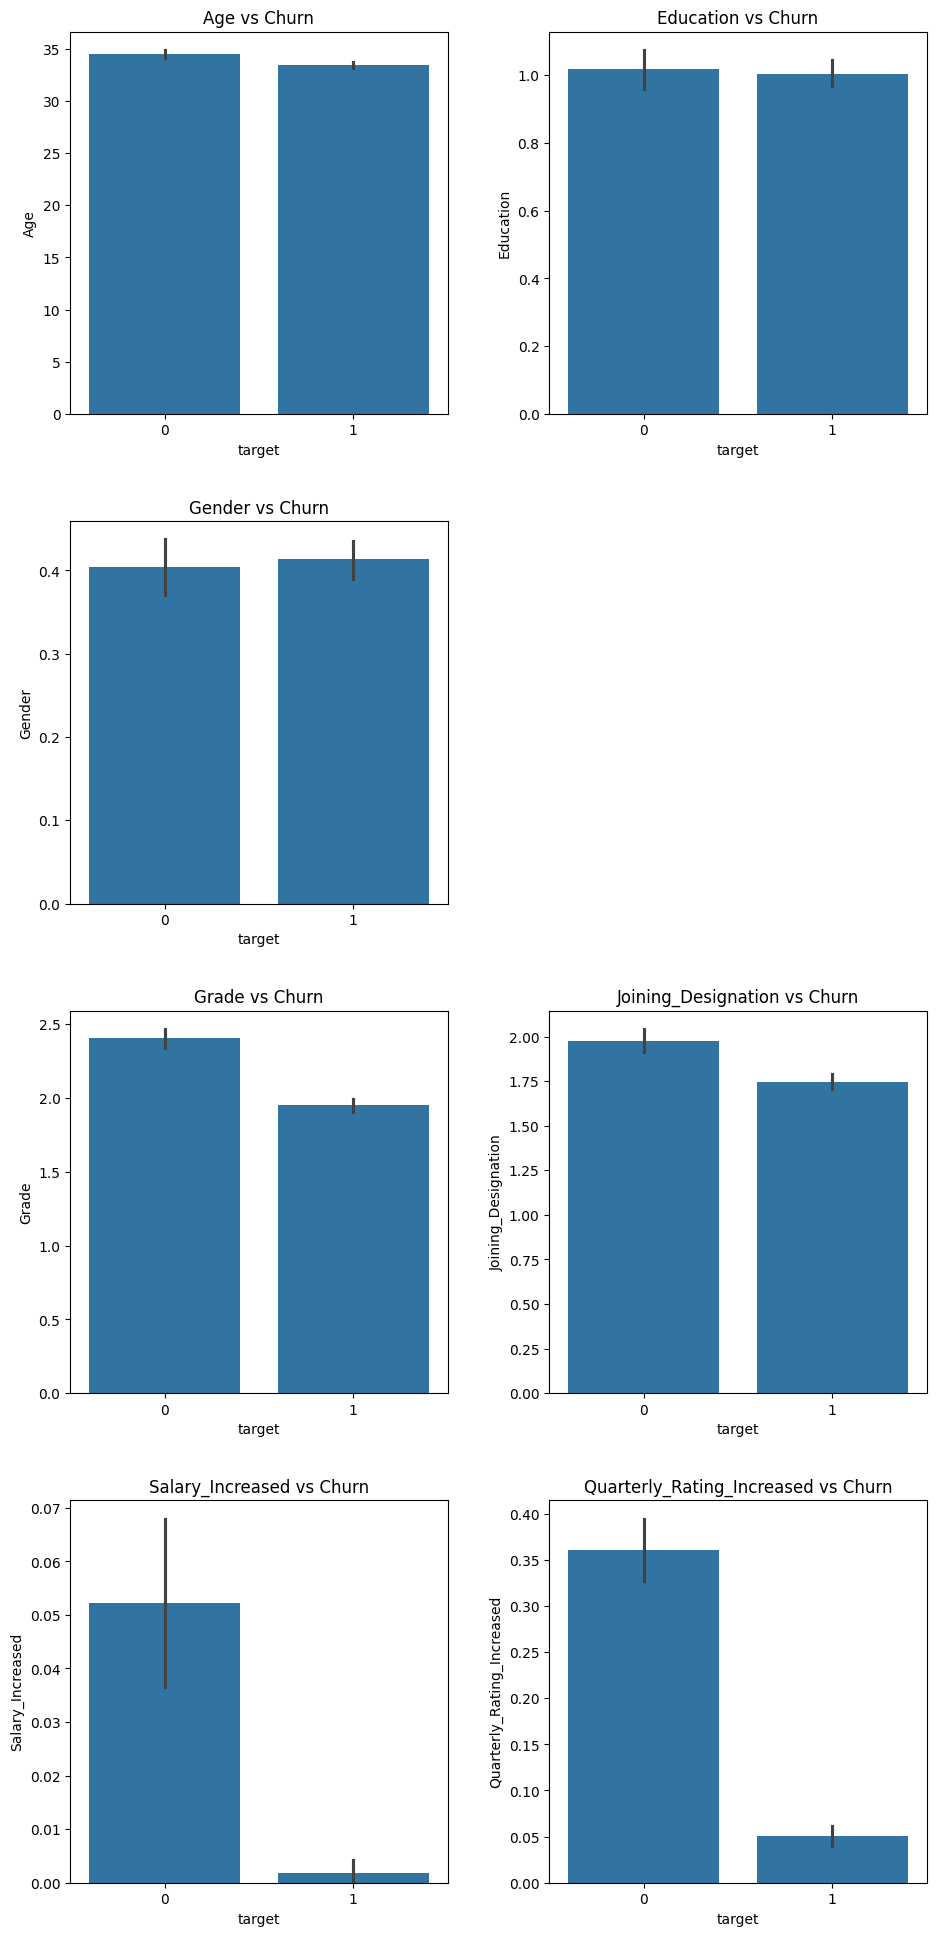

In [ ]:
plt.figure(figsize=(10,20))
#fig, axes = plt.subplots(1, 2, figsize=(20, 6))
plt.subplot(421)
sns.barplot(data=final_data, x="target", y="Age")
plt.title("Age vs Churn")

plt.subplot(422)
sns.barplot(data=final_data, x="target", y="Education")
plt.title("Education vs Churn")

plt.subplot(423)
sns.barplot(data=final_data, x="target", y="Gender")
plt.title("Gender vs Churn")

plt.subplot(425)
sns.barplot(data=final_data, x="target", y="Grade")
plt.title("Grade vs Churn")

plt.subplot(426)
sns.barplot(data=final_data, x="target", y="Joining_Designation")
plt.title("Joining_Designation vs Churn")

plt.subplot(427)
sns.barplot(data=final_data, x="target", y="Salary_Increased")
plt.title("Salary_Increased vs Churn")

plt.subplot(428)
sns.barplot(data=final_data, x="target", y="Quarterly_Rating_Increased")
plt.title("Quarterly_Rating_Increased vs Churn")

plt.tight_layout(pad=3)

- The proportion of Age, gender and education is more or less the same for both the employees who left the organization and those who did not leave.
- The employees who have their grade as 3 or 4 at the time of joining are less likely to leave the organization.
- The employees whose quarterly rating has increased are less likely to leave the organization.
- The employees whose monthly salary has not increased are more likely to leave the organization.

Correlation Analysis

In [ ]:
num_col_corr = final_data.select_dtypes(include=np.number)

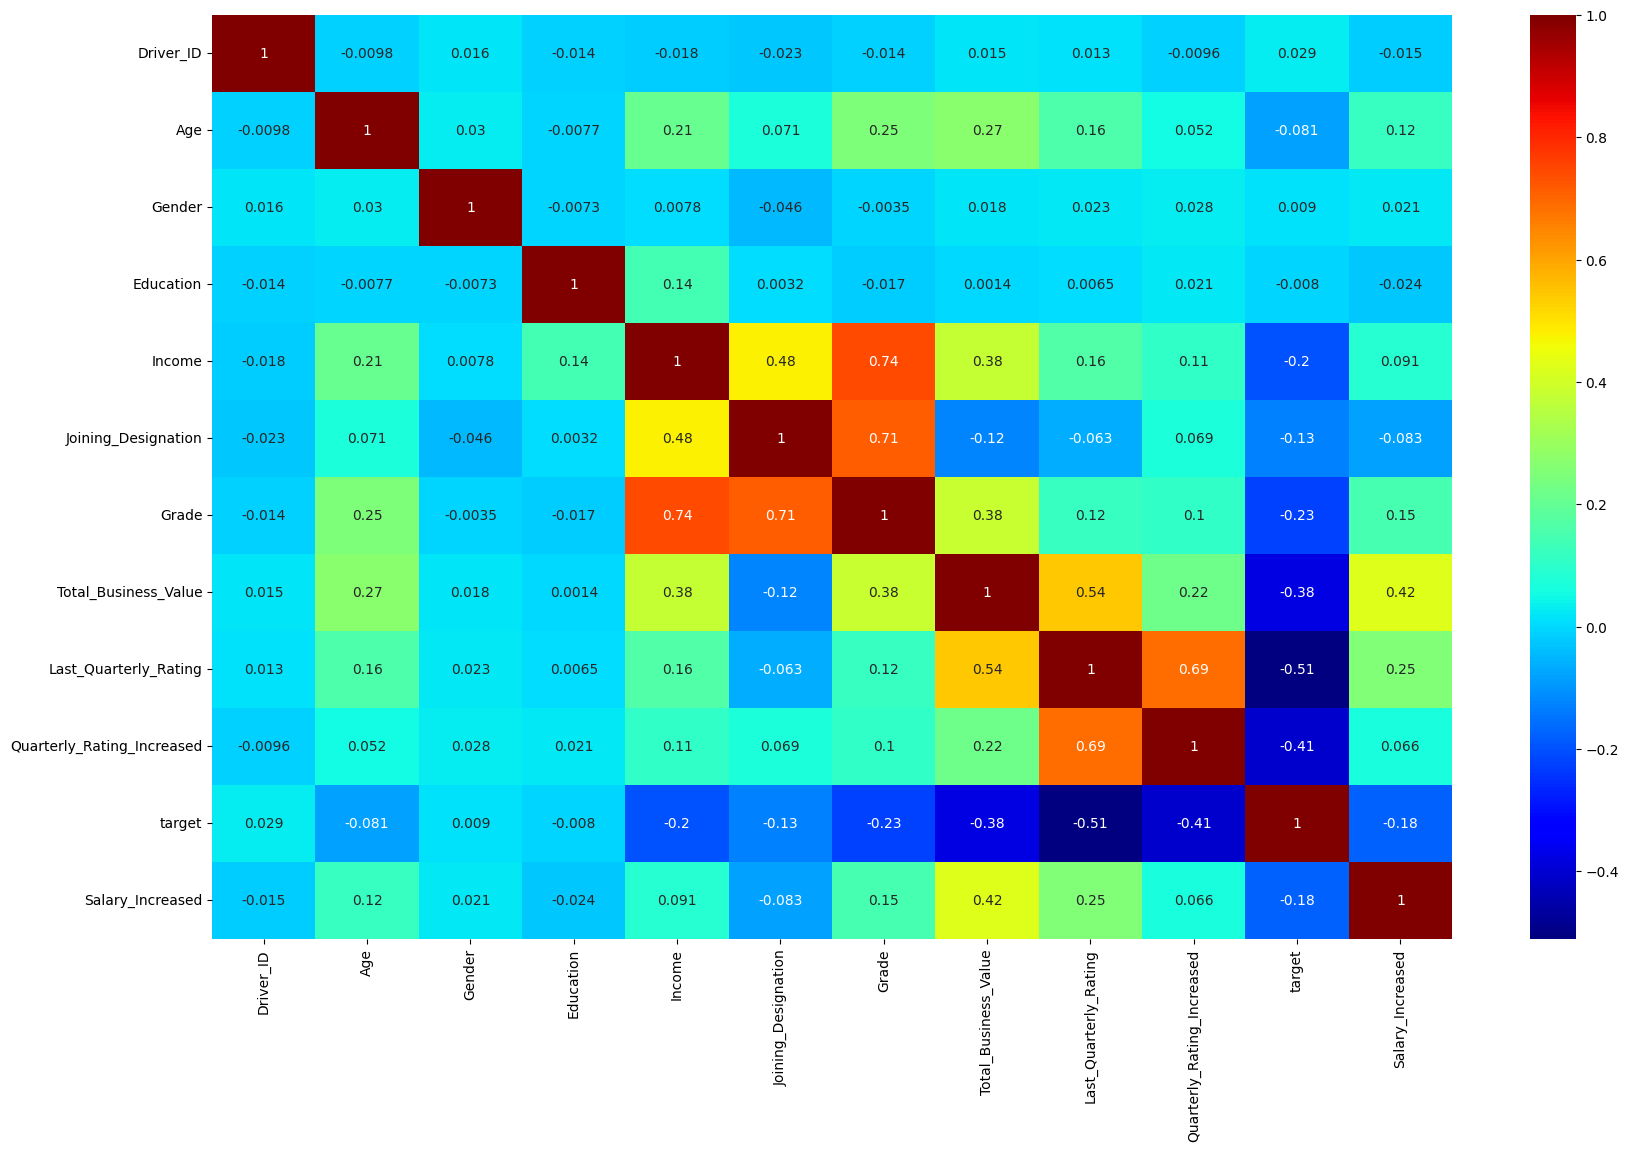

In [ ]:
plt.figure(figsize=(20,12))
sns.heatmap(num_col_corr.corr(method='pearson'), annot=True, cmap='jet')
plt.show()

- Income and Grade is highly correlated
- Joining Designation and Grade is highly correlated
- Total Business value and salary increament is correlated

**Column-Encoding:** since there is only one cat-column

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to the 'City' column
final_data['City_Encoded'] = label_encoder.fit_transform(final_data['City'])

# Display the first few rows with the new column
display(final_data.head())

,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased,target,Salary_Increased,City_Encoded
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0,1,0,15
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,0,0,0,26
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0,1,0,4
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0,1,0,28
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1,0,0,2


In [ ]:
final_data.head()

,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased,target,Salary_Increased,City_Encoded
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0,1,0,15
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,0,0,0,26
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0,1,0,4
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0,1,0,28
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1,0,0,2


In [ ]:
# Standardization(for training data)

X = final_data.drop(['Driver_ID','target','City'], axis=1)

X_cols = X.columns

scaler = MinMaxScaler()

X = scaler.fit_transform(X)

In [ ]:
X = pd.DataFrame(X)
X.columns = X_cols
X

,Age,Gender,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased,Salary_Increased,City_Encoded
0,0.189189,0.0,1.0,0.262508,0.00,0.00,0.032064,0.333333,0.0,0.0,0.535714
1,0.270270,0.0,1.0,0.316703,0.25,0.25,0.014326,0.000000,0.0,0.0,0.928571
2,0.594595,0.0,1.0,0.308750,0.25,0.25,0.017944,0.000000,0.0,0.0,0.142857
3,0.216216,0.0,0.0,0.200489,0.00,0.00,0.015570,0.000000,0.0,0.0,1.000000
4,0.270270,1.0,0.5,0.382623,0.50,0.50,0.027405,0.333333,1.0,0.0,0.071429
...,...,...,...,...,...,...,...,...,...,...,...
2376,0.351351,0.0,0.0,0.405626,0.25,0.50,0.239197,1.000000,1.0,0.0,0.571429
2377,0.351351,1.0,0.0,0.007643,0.00,0.00,0.014326,0.000000,0.0,0.0,1.000000
2378,0.648649,0.0,0.0,0.138588,0.25,0.25,0.043432,0.000000,0.0,0.0,0.357143
2379,0.189189,1.0,1.0,0.330673,0.00,0.00,0.024436,0.000000,0.0,0.0,0.428571


In [ ]:
# Train and Split
y = final_data['target']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2 , random_state=7, shuffle=True)

In [ ]:
print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)
print("y_train Shape: ", y_train.shape)
print("y_test Shape: ", y_test.shape)

X_train Shape:  (1904, 11)
X_test Shape:  (477, 11)
y_train Shape:  (1904,)
y_test Shape:  (477,)


In [ ]:
#Random Forest Classifier - Before Balancing
params = {
    "max_depth": [2, 3, 4],
    "n_estimators": [50, 100, 150, 200],
}

start_time = time.time()
random_forest = RandomForestClassifier(class_weight="balanced")
c = GridSearchCV(estimator=random_forest, param_grid=params, n_jobs=-1, cv=3, verbose=True, scoring='f1')

c.fit(X_train, y_train)

print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)
elapsed_time = time.time() - start_time

print("\nElapsed Time: ", elapsed_time)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params:  {'max_depth': 4, 'n_estimators': 50}
Best Score:  0.8609602420043098

Elapsed Time:  11.567307949066162


              precision    recall  f1-score   support

           0       0.73      0.57      0.64       148
           1       0.82      0.90      0.86       329

    accuracy                           0.80       477
   macro avg       0.78      0.74      0.75       477
weighted avg       0.79      0.80      0.79       477



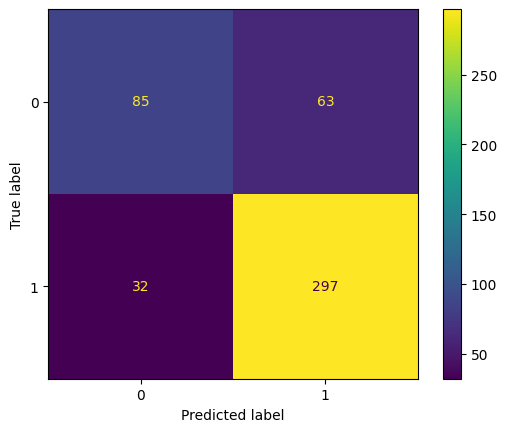

In [ ]:
y_pred = c.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=c.classes_).plot()

Random Forest Classifier with balanced class weight

- Out of all prediction, the measure for correctly predicted 0 is 73% and for 1 is 82% (Precision)
- Out of all actual 0, the measure for correctly predicted is 57% and for 1 is 90% (Recall)
As this is imbalanced dataset. We give importance to F1-Score metrics

- F1 Score of 0 is 64%
- F1 Score of 1 is 86%

In [ ]:
# Lets try out bootstrapped random forest using subsample
params = {
    "max_depth": [2, 3, 4],
    "n_estimators": [50, 100, 150, 200],
}

start_time = time.time()
random_forest = RandomForestClassifier(class_weight="balanced_subsample")
c = GridSearchCV(estimator=random_forest, param_grid=params, n_jobs=-1, cv=3, verbose=True, scoring='f1')

c.fit(X_train, y_train)

print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)
elapsed_time = time.time() - start_time

print("\nElapsed Time: ", elapsed_time)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params:  {'max_depth': 4, 'n_estimators': 150}
Best Score:  0.8626614420364539

Elapsed Time:  10.303195476531982


              precision    recall  f1-score   support

           0       0.70      0.58      0.63       148
           1       0.82      0.89      0.86       329

    accuracy                           0.79       477
   macro avg       0.76      0.73      0.74       477
weighted avg       0.79      0.79      0.79       477



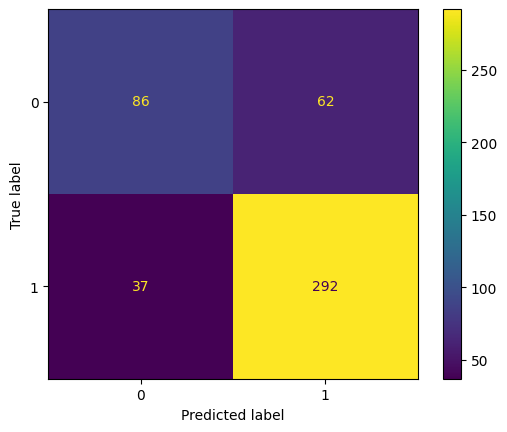

In [ ]:
y_pred = c.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=c.classes_).plot()

Random Forest Classifier with balanced class weight

- Out of all prediction, the measure for correctly predicted 0 is 75% and for 1 is 83% (Precision)
- Out of all actual 0, the measure for correctly predicted is 57% and for 1 is 91% (Recall)

- As this is imbalanced dataset. We give importance to F1-Score metrics

- F1 Score of 0 is 65%
- F1 Score of 1 is 87%

- **There is not much significant difference in the matrices observed for bootstrapped Random Forest and Weighted Random Forest

Lets try balancing**

**Balancing Dataset using SMOTE**

- As the target variable is imbalanced towards 1. We will use SMOTE to balance the dataset

In [ ]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

sm = SMOTE(random_state = 7)
X_train, y_train = sm.fit_resample(X_train, y_train.ravel())

print('After OverSampling, the shape of train_X: {}'.format(X_train.shape))
print('After OverSampling, the shape of train_y: {} \n'.format(y_train.shape))

print("After OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("After OverSampling, counts of label '0': {}".format(sum(y_train == 0)))


Before OverSampling, counts of label '1': 1287
Before OverSampling, counts of label '0': 617 

After OverSampling, the shape of train_X: (2574, 11)
After OverSampling, the shape of train_y: (2574,) 

After OverSampling, counts of label '1': 1287
After OverSampling, counts of label '0': 1287


/tmp/ipython-input-60-4086381440.py:5: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  X_train, y_train = sm.fit_resample(X_train, y_train.ravel())


**Ensemble Learning: Bagging**

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params:  {'max_depth': 4, 'n_estimators': 100}
Best Score:  0.784172566489009

Elapsed Time:  11.600805282592773
              precision    recall  f1-score   support

           0       0.71      0.57      0.64       148
           1       0.82      0.90      0.86       329

    accuracy                           0.80       477
   macro avg       0.77      0.74      0.75       477
weighted avg       0.79      0.80      0.79       477



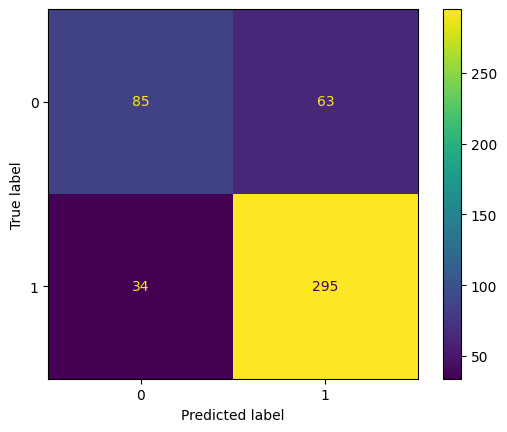

In [ ]:
params = {
    "max_depth": [2, 3, 4],
    "n_estimators": [50, 100, 150, 200],
}

start_time = time.time()
random_forest = RandomForestClassifier(class_weight="balanced_subsample")
c = GridSearchCV(estimator=random_forest, param_grid=params, n_jobs=-1, cv=3, verbose=True, scoring='f1')

c.fit(X_train, y_train)

print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)
elapsed_time = time.time() - start_time

print("\nElapsed Time: ", elapsed_time)
y_pred = c.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=c.classes_).plot()


**Random Forest Classifier with balanced class weight**

- Out of all prediction, the measure for correctly predicted 0 is 74% and for 1 is 83% (Precision)
- Out of all actual 0, the measure for correctly predicted is 57% and for 1 is 91% (Recall)
- As this is imbalanced dataset. We give importance to F1-Score metrics

- F1 Score of 0 is 65%
- F1 Score of 1 is 87%

**ROC-AUC Curve**

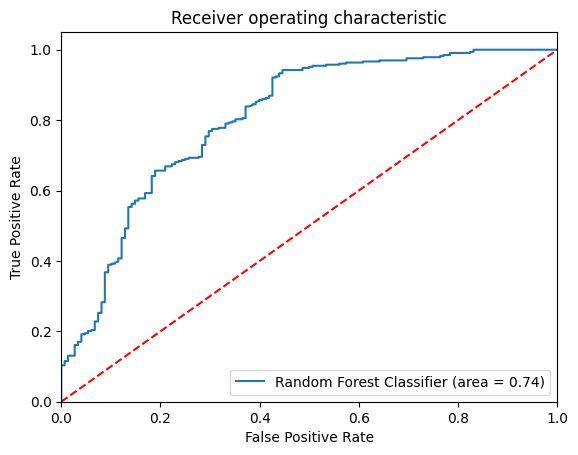

In [ ]:
logit_roc_auc=roc_auc_score(y_test,y_pred)
fpr,tpr,thresholds=roc_curve(y_test,c.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr,tpr,label='Random Forest Classifier (area = %0.2f)' % logit_roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

**Ensemble Learning: Boosting¶**

Fitting 3 folds for each of 360 candidates, totalling 1080 fits
Best Params:  {'learning_rate': 0.2, 'loss': 'exponential', 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.8}
Best Score:  0.8162393162393163

 Elapsed Time:  330.6800785064697
              precision    recall  f1-score   support

           0       0.63      0.59      0.61       148
           1       0.82      0.84      0.83       329

    accuracy                           0.76       477
   macro avg       0.72      0.71      0.72       477
weighted avg       0.76      0.76      0.76       477



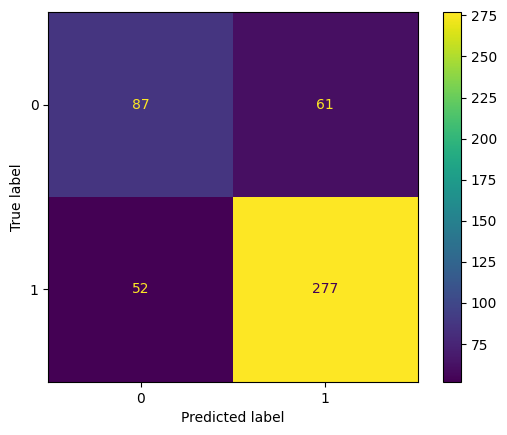

In [ ]:
# Gradient Boosting Classifier
params = {
    "max_depth": [2, 3, 4],
    "loss": ["log_loss", "exponential"],
    "subsample": [0.1, 0.2, 0.5, 0.8, 1],
    "learning_rate": [0.1, 0.2, 0.3],
    "n_estimators": [50,100,150,200]
}

gbdt = GradientBoostingClassifier()
start_time = time.time()
c = GridSearchCV(estimator=gbdt, cv=3, n_jobs=-1, verbose=True, param_grid=params)

c.fit(X_train, y_train)
print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)

elapsed_time = time.time() - start_time
print("\n Elapsed Time: ", elapsed_time)

y_pred = c.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=c.classes_).plot()

**XGBoost Classifier**

XGBoost Classifier Score:  0.7568134171907757

               precision    recall  f1-score   support

           0       0.61      0.59      0.60       148
           1       0.82      0.83      0.82       329

    accuracy                           0.76       477
   macro avg       0.72      0.71      0.71       477
weighted avg       0.76      0.76      0.76       477



/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [18:19:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


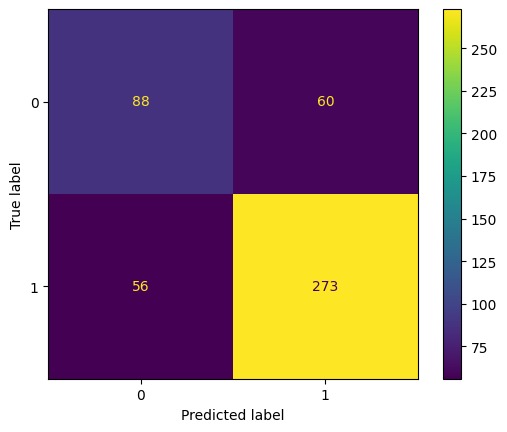

In [ ]:
model = xgb.XGBClassifier(class_weight = "balanced")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("XGBoost Classifier Score: ", model.score(X_test, y_test))
print("\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot()

**XGBoost Classifier with balanced class weight**

- Out of all prediction, the measure for correctly predicted 0 is 62% and for 1 is 81% (Precision)
- Out of all actual 0, the measure for correctly predicted is 57% and for 1 is 84% (Recall)
- As this is imbalanced dataset. We give importance to F1-Score metrics

- F1 Score of 0 is 60%
- F1 Score of 1 is 82%

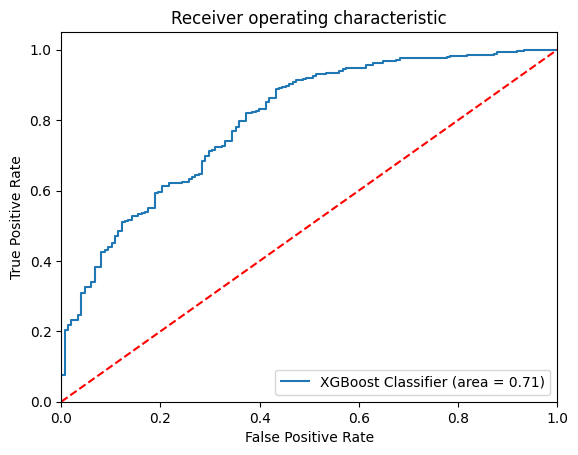

In [ ]:
logit_roc_auc=roc_auc_score(y_test,y_pred)
fpr,tpr,thresholds=roc_curve(y_test,c.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr,tpr,label='XGBoost Classifier (area = %0.2f)' % logit_roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

**Final Result Evaluation**

- We observe that we are not getting very high recall on target 0 which may be due to small unbalanced dataset.
- Higher precision means that an algorithm returns more relevant results than irrelevant ones, and high recall means that an algorithm returns most of the relevant results (whether or not irrelevant ones are also returned).
- **We observe that Random Forest with SMOTE outperforms rest of the models and has higher recall and precision values.**
- The Random Forest method out of all predicted 0 the measure of correctly predicted is 73%, and for 1 it is 82%(Precision).
- The Random Forest method out of all actual 0 the measure of correctly predicted is 56%, and for 1 it is 91%(Recall).
- The ROC-AUC curve area for Random Forest Classifier is 0.74
- **Gradient Boosting Classifier Result**
- Out of all prediction, the measure for correctly predicted 0 is 62% and for 1 is 82% (Precision)
- Out of all actual 0, the measure for correctly predicted is 60% and for 1 is 83% (Recall)
- The ROC-AUC curve area for Gradient Boosting Decision Tree Classifier is 0.71
- **XGBoost Classifier Result**
- Out of all prediction, the measure for correctly predicted 0 is 62% and for 1 is 81% (Precision)
- Out of all actual 0, the measure for correctly predicted is 57% and for 1 is 84% (Recall)
- The ROC-AUC curve area for XGBoost Classifier is 0.71

Feature Importance of the best model so far
Random Forest Classifier outperforms the rest of the modal.

Best parameters

Best Params: {'max_depth': 4, 'n_estimators': 50}

In [ ]:
rf = RandomForestClassifier(max_depth = 4, n_estimators= 50, class_weight="balanced")

rf.fit(X_train, y_train)
print("Score of RandomForestClassifier: ", rf.score(X_test, y_test))

Score of RandomForestClassifier:  0.7987421383647799


In [ ]:
importances = rf.feature_importances_
importances

array([0.0285207 , 0.00136905, 0.0028702 , 0.04676265, 0.06736714,
       0.06708638, 0.22356676, 0.39694119, 0.15100212, 0.00212876,
       0.01238506])

In [ ]:
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

<Figure size 1500x700 with 0 Axes>

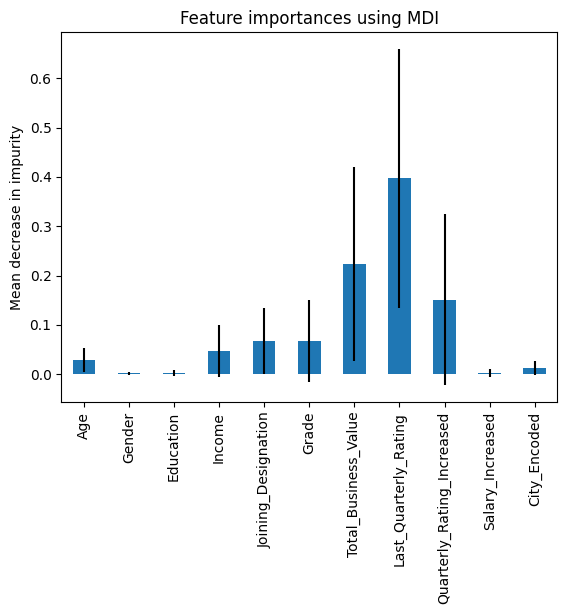

In [ ]:
feature_importances = pd.Series(importances, X_train.columns)

plt.figure(figsize=(15,7))
fig, ax = plt.subplots()
feature_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")

plt.show()

**Insights**

Last_Quarterly_Rating, Total_Business_Value & Quarterly_Rating_Increased are the most important features.

**Actionable Insights and Recommendation**

- Out of 2381 drivers 1616 have left the company.
- We need to incentivise the drivers overtime or other perks to overcome churning
- The employees whose quarterly rating has increased are less likely to leave the organization.
- Company needs to implement the reward system for the customer who provide the feedback and rate drivers
- The employees whose monthly salary has not increased are more likely to leave the organization.
- Company needs to get in touch with those drivers whose monthly salary has not increased and help them out to earn more by provider bonus and perks.
- Out of 2381 employees, 1744 employees had their last quarterly rating as 1.
- Out of 2381 employees, the quarterly rating has not increased for 2076 employees. This is red flag for the company which needs to regulate.
- Company needs to look why customers are not rating drivers.
- Last_Quarterly_Rating, Total_Business_Value & Quarterly_Rating_Increased are the most important features. Company needs to tracks these features as predicators
- We observe that we are not getting very high recall on target 0 which may be due to small unbalanced dataset. More data will overcome this issue.
- The Random Forest Classifier attains the Recall score of 91% for the driver who left the company. Which indicates that model is performing the decent job.